# About

Kriem-RO is a private, non-profit server dedicated to the classic MMORPG Ragnarok Online, a 2.5D game originally launched in 2004 by Gravity Games. Ragnarok Online offers a rich array of activities, including monster hunting, leveling up, acquiring gear, forming parties, and engaging in player-versus-player (PvP) combat. One of the game's most iconic features is the War of Emperium (WoE), where guilds compete for control of castles within the realms of Midgard.

As a passionate fan of both the game and its PvP mechanics, I decided to create Kriem-RO, an instant server where players can immediately access all equipment and dive straight into intense PvP action. The server entered beta testing in October 2023, with the official release following in July 2024. Since then, we've welcomed a growing community of players who have enjoyed countless battles on the server. You can find more information about Kriem-RO on our official website: https://kriemro.com/home.

This analysis draws on data collected over the past year and focuses on two major datasets:

Char_info:

 - Char_id: A unique identifier for each character.
 - Name: The character's name.
 - Class: The numerical identifier for the character's class.

Woe_info:

 - Woe_ranking_id: A unique identifier for each character's WoE ranking.
 - Char_id: The unique identifier for the character.
 - Guild_id: A unique identifier for the guild.
 - Woe_id: A unique identifier for the WoE event.
 - Kill: The number of kills a character has achieved.
 - Death: The number of times a character has died.
 - Emperium_break: The number of Emperiums a player has broken.
 - Created_at: The date of the WoE event.
 - Guild_name: The name of the guild the character belongs to.


This analysis will be split into sections for better clarity, allowing us to explore the data in-depth and gain insights into the PvP dynamics within Kriem-RO.

In [1]:
# Imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Datasets

char = pd.read_csv('Kriem/char.csv')
woe = pd.read_csv('Kriem/woe_ranking.csv')

# Dataset Update

char_info = char[['char_id','name','class']]
woe_info = woe.drop(columns=['updated_at'])
woe_info['created_at'] = pd.to_datetime(woe_info['created_at']).dt.normalize()

# Changing guild number to guild name

guild_mapping = {
    3: 'Lazy Smokies',
    4: 'Russian Squad',
    5: 'Ravage',
    7: 'Nightfall',
    60: 'Strong',
    85: 'Sigma',
    36: 'Draft Blue',
    35: 'Draft Red',
    37: 'Draft Green',
    62: 'Draft Yellow'
}

woe_info['guild_name'] = woe_info.guild_id.map(guild_mapping)
woe_info = woe_info.dropna().reset_index(drop=True)

# Unifying to a single table

tables = pd.merge(woe_info, char_info, on='char_id')

# Guild df

guild_rank = ['Russian Squad','Ravage','Nightfall','Lazy Smokies','Sigma']
guild_rank = tables[tables['guild_name'].isin(guild_rank)]

# Draft df

draft_rank = ['Draft Red','Draft Blue','Draft Green']
draft_rank = tables[tables['guild_name'].isin(draft_rank)]

# Guild analysis

In [2]:
# Guild Kills

guild_kill = guild_rank.groupby('guild_name')['kill'].sum().reset_index()
guild_kill.sort_values(by='kill', ascending=False)

,guild_name,kill
2,Ravage,19670
3,Russian Squad,15429
1,Nightfall,10563
0,Lazy Smokies,2438
4,Sigma,1687


In [3]:
# Guild deaths

guild_death = guild_rank.groupby('guild_name')['death'].sum().reset_index()
guild_death.sort_values(by='death', ascending=False)

,guild_name,death
3,Russian Squad,17642
2,Ravage,16000
1,Nightfall,10480
4,Sigma,4063
0,Lazy Smokies,3170


In [4]:
# Guild kill / death

guild_kda = guild_rank.groupby('guild_name')[['kill','death']].sum().reset_index()
guild_kda['kd'] = guild_kda['kill'] / guild_kda['death']
guild_kda.sort_values(by='kd', ascending=False)

,guild_name,kill,death,kd
2,Ravage,19670,16000,1.229375
1,Nightfall,10563,10480,1.007920
3,Russian Squad,15429,17642,0.874561
0,Lazy Smokies,2438,3170,0.769085
4,Sigma,1687,4063,0.415210


In [5]:
# Emp break

guild_emp = guild_rank.groupby('guild_name')['emperium_break'].sum().reset_index()
guild_emp = guild_emp.sort_values(by='emperium_break', ascending=False)
guild_emp

,guild_name,emperium_break
2,Ravage,58
3,Russian Squad,50
1,Nightfall,39
0,Lazy Smokies,9
4,Sigma,4


In [6]:
# Comparing GvG

guild_rank_2 = guild_rank
change_guild_name = {
    'Ravage': 'RvG',
    'Russian Squad': 'RS',
    'Nightfall': 'NF',
    'Lazy Smokies': 'LS',
    'Sigma': 'SG'
}

guild_rank_2.guild_name = guild_rank_2.guild_name.replace(change_guild_name)

guild_rank_summary = guild_rank_2.groupby('created_at').agg({
    'death': 'sum',
    'kill': 'sum',
    'guild_name': lambda x: ', '.join(sorted(x.unique()))
})

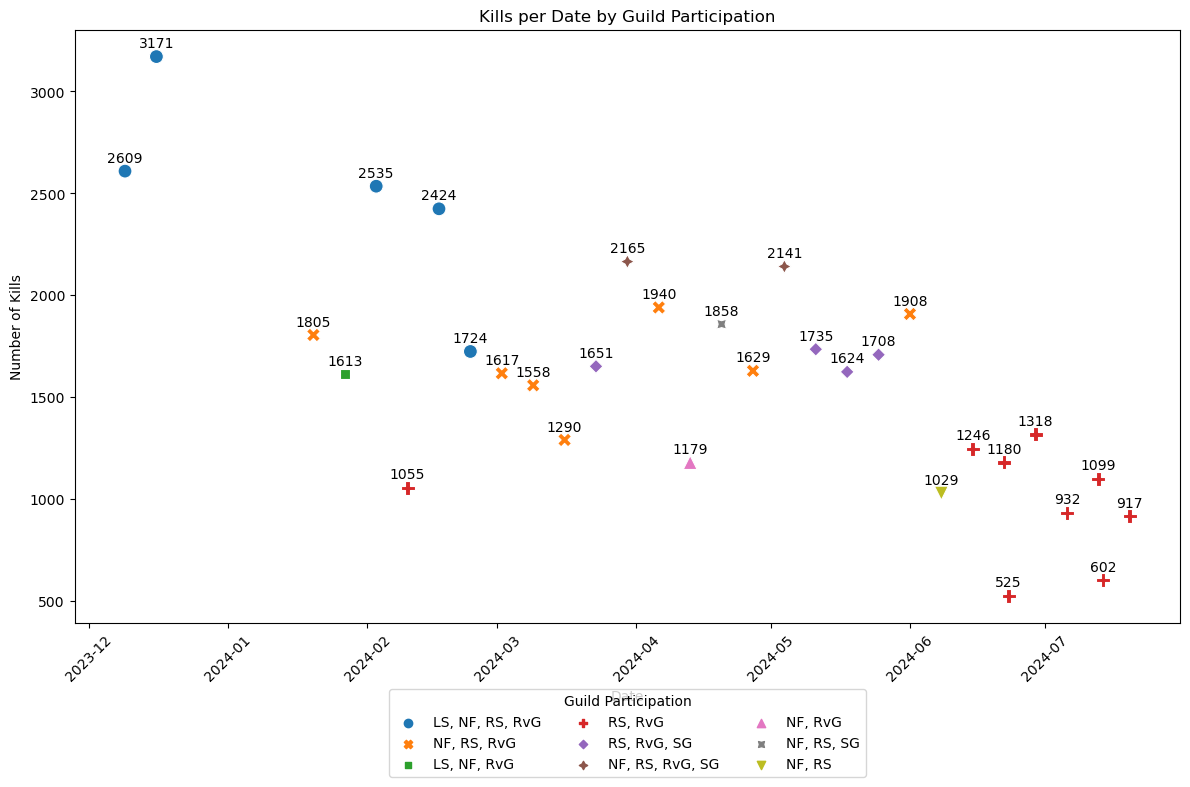

In [7]:
# Graphic Kills per date

guild_rank_summary = guild_rank_summary[guild_rank_summary['kill'] > 0]

guild_rank_summary.reset_index(inplace=True)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=guild_rank_summary, x='created_at', y='kill', hue='guild_name', style='guild_name', s=100)


plt.title('Kills per Date by Guild Participation')
plt.xlabel('Date')
plt.ylabel('Number of Kills')
plt.xticks(rotation=45)


for i in range(guild_rank_summary.shape[0]):
    plt.text(guild_rank_summary['created_at'].iloc[i], 
             guild_rank_summary['kill'].iloc[i] + 30,
             guild_rank_summary['kill'].iloc[i],
             ha='center', va='bottom')

plt.legend(title='Guild Participation', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()

plt.show()

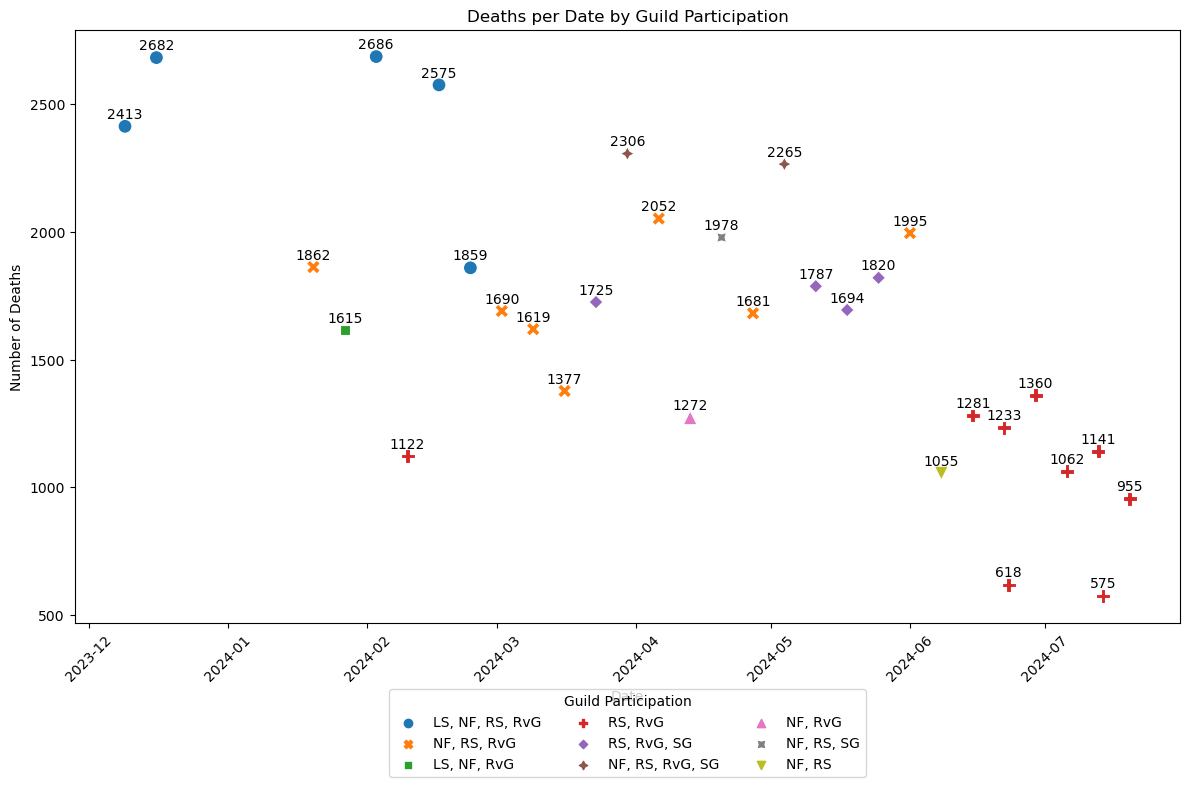

In [8]:
# Graphic deaths per date

guild_rank_summary = guild_rank_summary[guild_rank_summary['death'] > 0]

guild_rank_summary.reset_index(inplace=True)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=guild_rank_summary, x='created_at', y='death', hue='guild_name', style='guild_name', s=100)

plt.title('Deaths per Date by Guild Participation')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45)

for i in range(guild_rank_summary.shape[0]):
    plt.text(guild_rank_summary['created_at'].iloc[i], 
             guild_rank_summary['death'].iloc[i] + 20,
             guild_rank_summary['death'].iloc[i],
             ha='center', va='bottom')


plt.legend(title='Guild Participation', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()

plt.show()

In [9]:
# New df for k/d

table_kd = guild_rank
table_kd['kill_death_ratio'] = table_kd['kill'] / table_kd['death']
grouped = table_kd.groupby(['created_at', 'guild_name'])

best_ratios = grouped.apply(lambda x: x.sort_values(by='kill_death_ratio', ascending=False).head(1))


guild_kd = table_kd.groupby(['created_at', 'guild_name']).agg({
    'kill': 'sum',
    'death': 'sum'
}).reset_index()

guild_kd['kill_death_ratio'] = guild_kd['kill'] / guild_kd['death']

best_guild_kd = guild_kd.sort_values(by=['guild_name', 'kill_death_ratio'], ascending=[True, False]).reset_index(drop=True)
best_guild_kd

,created_at,guild_name,kill,death,kill_death_ratio
0,2024-01-27,LS,301,333,0.903904
1,2023-12-16,LS,659,732,0.900273
2,2023-12-09,LS,493,600,0.821667
3,2024-02-17,LS,439,608,0.722039
4,2024-02-03,LS,313,508,0.616142
...,...,...,...,...,...
85,2024-05-18,SG,244,501,0.487026
86,2024-03-23,SG,301,632,0.476266
87,2024-05-11,SG,239,691,0.345876
88,2024-03-30,SG,148,570,0.259649


In [10]:
# K/d per date

guild_kd = table_kd.groupby(['created_at', 'guild_name']).agg({
    'kill': 'sum',
    'death': 'sum'
}).reset_index()

guild_kd = guild_kd[guild_kd['death'] > 0].copy()

guild_kd['kill_death_ratio'] = guild_kd['kill'] / guild_kd['death']

best_kd_per_date = guild_kd.loc[guild_kd.groupby('created_at')['kill_death_ratio'].idxmax().dropna()]

best_kd_per_date = best_kd_per_date.sort_values(by='created_at').reset_index(drop=True)

best_kd_per_date

,created_at,guild_name,kill,death,kill_death_ratio
0,2023-12-09,NF,783,564,1.388298
1,2023-12-16,RvG,1001,634,1.578864
2,2024-01-20,RvG,648,599,1.081803
3,2024-01-27,RvG,739,610,1.211475
4,2024-02-03,NF,688,597,1.152429
5,2024-02-10,RvG,723,341,2.120235
6,2024-02-17,RS,794,672,1.181548
7,2024-02-24,RS,638,531,1.201507
8,2024-03-02,RS,675,605,1.115702
9,2024-03-09,RS,566,367,1.542234


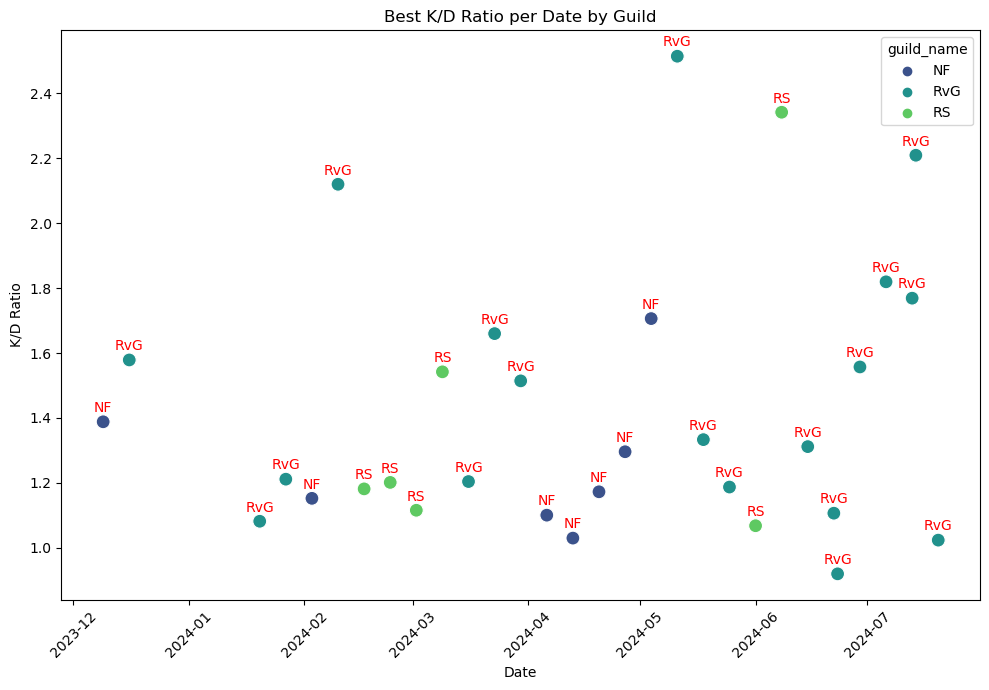

In [11]:
# Graphic k/d per date

plt.figure(figsize=(10, 7))

sns.scatterplot(x='created_at', y='kill_death_ratio', hue='guild_name', data=best_kd_per_date, s=100, palette='viridis')

for i in range(best_kd_per_date.shape[0]):
    plt.text(x=best_kd_per_date['created_at'].iloc[i], 
             y=best_kd_per_date['kill_death_ratio'].iloc[i] + 0.03, 
             s=best_kd_per_date['guild_name'].iloc[i], 
             fontdict=dict(color='red', size=10),
             ha='center')

plt.xlabel('Date')
plt.ylabel('K/D Ratio')
plt.title('Best K/D Ratio per Date by Guild')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [12]:
# Won by Emp breaks

guild_eb = table_kd.groupby(['created_at', 'guild_name']).agg({
    'emperium_break': 'sum'
}).reset_index()

guild_eb = guild_eb[guild_eb['emperium_break'] > 0].copy()

most_eb_per_date = guild_eb.loc[guild_eb.groupby('created_at')['emperium_break'].idxmax().dropna()]
most_eb_per_date

guild_rank = most_eb_per_date['guild_name'].value_counts().reset_index()

guild_rank.columns = ['guild_name', 'Number of Emps']

guild_rank = guild_rank.sort_values(by='Number of Emps', ascending=False).reset_index(drop=True)
guild_rank['rank'] = guild_rank['Number of Emps'].rank(method='min', ascending=False)
guild_rank

,guild_name,Number of Emps,rank
0,RS,11,1.0
1,RvG,10,2.0
2,NF,8,3.0
3,LS,1,4.0


In [13]:
# Won by k/d

guild_rank = best_kd_per_date['guild_name'].value_counts().reset_index()

# Rename the columns for clarity
guild_rank.columns = ['guild_name', 'k/d']

# Sort by the number of appearances in descending order
guild_rank = guild_rank.sort_values(by='k/d', ascending=False).reset_index(drop=True)
guild_rank

,guild_name,k/d
0,RvG,18
1,NF,7
2,RS,6


# Draft Analysis

In [14]:
# Draft Kills

draft_kill = draft_rank.groupby('guild_name')['kill'].sum().reset_index()
draft_kill.sort_values(by='kill', ascending=False)

,guild_name,kill
0,Draft Blue,6964
2,Draft Red,6940
1,Draft Green,4335


In [15]:
# Draft deaths

draft_death = draft_rank.groupby('guild_name')['death'].sum().reset_index()
draft_death.sort_values(by='death', ascending=False)

,guild_name,death
0,Draft Blue,7773
2,Draft Red,6730
1,Draft Green,4982


In [16]:
# Draft kill / death

draft_kd = draft_rank.groupby('guild_name')[['kill','death']].sum().reset_index()
draft_kd['kd'] = draft_kd['kill'] / draft_kd['death']
draft_kd.sort_values(by='kd', ascending=False)

,guild_name,kill,death,kd
2,Draft Red,6940,6730,1.031204
0,Draft Blue,6964,7773,0.895922
1,Draft Green,4335,4982,0.870132


In [17]:
# Draft Emp break

draft_emp = draft_rank.groupby('guild_name')['emperium_break'].sum().reset_index()
draft_emp = draft_emp.sort_values(by='emperium_break', ascending=False)
draft_emp

,guild_name,emperium_break
0,Draft Blue,40
2,Draft Red,33
1,Draft Green,24


In [18]:
# Most draft players

draft_rank.name.value_counts().head(10)

name
TheVoid           15
Feyre             14
Vee Vee           13
Battle Born       12
CC BOT            11
Dratini           11
Kumbaya           10
Heda              10
Proix             10
Pasa Me a Bufa    10
Name: count, dtype: int64

# Player Analysis

In [19]:
tables

,woe_ranking_id,char_id,guild_id,woe_id,kill,death,emperium_break,created_at,guild_name,name,class
0,1,152039,37,1,74,30,0,2023-12-03,Draft Green,SuperShy,4078
1,526,152039,36,6,74,38,0,2023-12-23,Draft Blue,SuperShy,4078
2,644,152039,5,11,73,27,0,2024-01-20,Ravage,SuperShy,4078
3,1092,152039,5,20,69,27,0,2024-02-17,Ravage,SuperShy,4078
4,1097,152039,36,21,35,25,1,2024-02-18,Draft Blue,SuperShy,4078
...,...,...,...,...,...,...,...,...,...,...,...
2940,3043,154957,4,74,8,30,0,2024-07-20,Russian Squad,zaraki,4060
2941,3052,154972,5,74,9,23,0,2024-07-20,Ravage,kApE,4060
2942,3060,154975,4,74,68,14,0,2024-07-20,Russian Squad,picky,4218
2943,3065,154978,4,74,102,25,0,2024-07-20,Russian Squad,Pisvn,4078


In [20]:
# Most Kills

char_kill = tables.groupby('name')['kill'].sum()
char_kill = char_kill.sort_values(ascending=False).head(10)
char_kill

name
TheVoid                  4114
Feyre                    3975
King Crimson             3682
Proix                    3393
Kumbaya                  2247
gato                     1960
Battle Born              1933
Louise de la Valliere    1889
KinGofpaiN               1602
Super Shy                1464
Name: kill, dtype: int64

In [21]:
# Most Deaths

char_death= tables.groupby('name')['death'].sum()
char_death = char_death.sort_values(ascending=False).head(10)
char_death

name
Proix           1175
TheVoid         1173
Heda             976
wind             942
gato             864
ment             841
Brean            792
Kumbaya          780
Dratini          697
King Crimson     695
Name: death, dtype: int64

In [22]:
# Most emp breaks

char_emp = tables.groupby('name')['emperium_break'].sum()
char_emp = char_emp.sort_values(ascending=False).head(10)
char_emp

name
Brean         15
ment          12
Heda          12
gato          10
SoCool         7
CC BOT         6
Ivanard        5
ProixBragi     5
Diotar         4
Skar           4
Name: emperium_break, dtype: int64

In [23]:
# Most WoE played

mwp = tables.name.value_counts().head(10)
mwp

name
TheVoid         42
Heda            33
Proix           32
Feyre           32
King Crimson    30
Brean           29
ment            29
Chamomile       28
Dratini         27
Sagaty          27
Name: count, dtype: int64

In [24]:
# Best k/d over 500 kills

kd_char = tables.groupby('name')[['kill','death']].sum()
kd_char['kd'] = kd_char.kill / kd_char.death
kd_char = kd_char.query('kill > 500')
kd_char = kd_char.sort_values(by='kd', ascending=False).head(10)
kd_char

,kill,death,kd
name,,,
feyfeyfey,1199,151,7.940397
Feyre,3975,549,7.240437
Pastel,814,136,5.985294
Skar,1031,181,5.696133
King Crimson,3682,695,5.297842
IntoTheUnknowN,1339,291,4.601375
Super Shy,1464,360,4.066667
Bahamut,598,150,3.986667
Ursa,623,159,3.918239
